# GAT-Based Cell Clustering: Transfer Learning for scRNA-Seq

**Approach:** Train an unsupervised Graph Attention Network (GAT) autoencoder on two scRNA-seq datasets (Zeisel, Pollen), then transfer the learned weights to cluster a held-out dataset (Klein) and compare against KMeans and SC3 baselines.

| Dataset | Accession | Cells | Source | Role |
|---------|-----------|-------|--------|------|
| Zeisel | GSE60361 | 3,005 | Mouse Cerebral Cortex | Training |
| Pollen | GSE59739 | ~300 | Human Tissue/Neural | Training |
| Klein | GSE65525 | ~2,700 | Mouse Embryonic Stem Cells | Demo/Transfer |
| Semrau | GSE79578 | 3,456 | Mouse Embryonic Stem Cells | Training | 


In [2]:
# ============================================================
# Section 1: Setup
# ============================================================

import copy
import gzip
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sc3s
import scanpy as sc
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATConv

INPUT_DIR = Path("data/input")
INPUT_DIR.mkdir(parents=True, exist_ok=True)

def fetch_file(url: str, dest: Path):
    if not dest.exists() or dest.stat().st_size == 0:
        print(f"Downloading {dest.name}...")
        urllib.request.urlretrieve(url, dest)
        print(f"  Done: {dest.stat().st_size / 1e6:.1f} MB")
    else:
        print(f"Already have {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")


## 2. Data Loading

Download all four datasets from GEO into `data/input/`.


In [3]:
# ============================================================
# Load Zeisel (GSE60361) - Training set 1
# ============================================================

zeisel_expr_path = INPUT_DIR / "GSE60361_C1-3005-Expression.txt"
zeisel_labels_path = INPUT_DIR / "Zeisel_cell_label.csv"

# Expression file is large (115MB) - must be manually placed or downloaded separately
if not zeisel_expr_path.exists():
    print("NOTE: GSE60361 expression file too large for auto-download.")
    print("Place GSE60361_C1-3005-Expression.txt in data/input/")
else:
    expr_df = pd.read_csv(zeisel_expr_path, sep="\t", index_col=0)
    zeisel_adata = sc.AnnData(
        X=expr_df.T.values.astype(np.float32),
        obs=pd.DataFrame(index=expr_df.columns),
        var=pd.DataFrame(index=expr_df.index)
    )
    zeisel_adata.obs_names_make_unique()
    zeisel_adata.var_names_make_unique()

    # Attach labels
    if zeisel_labels_path.exists():
        labels_df = pd.read_csv(zeisel_labels_path, index_col=0)
        zeisel_adata.obs["cell_type"] = labels_df.reindex(zeisel_adata.obs_names)["Label"].values.astype(str)

    print(f"Zeisel: {zeisel_adata.n_obs} cells x {zeisel_adata.n_vars} genes")
    print(f"Labels: {zeisel_adata.obs['cell_type'].value_counts().to_dict()}")


Zeisel: 3005 cells x 19972 genes
Labels: {'3': 939, '4': 820, '2': 399, '1': 290, '6': 235, '7': 224, '5': 98}


c:\Users\Patrick\Documents\NJIT\Summer2026\Project\projenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# ============================================================
# Load Pollen (GSE59739) - Training set 3
# ============================================================

pollen_expr_path = INPUT_DIR / "GSE59739_DataTable.txt.gz"
base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE59nnn/GSE59739"
fetch_file(f"{base_url}/suppl/GSE59739_DataTable.txt.gz", pollen_expr_path)

pollen_matrices = []
for gpl in ["GPL11002", "GPL13112"]:
    mat_file = INPUT_DIR / f"GSE59739-{gpl}_series_matrix.txt.gz"
    fetch_file(f"{base_url}/matrix/{mat_file.name}", mat_file)
    pollen_matrices.append(mat_file)

# Parse metadata
meta_dfs = []
for mat_file in pollen_matrices:
    sample_ids, cell_names, characteristics = [], [], {}
    with gzip.open(mat_file, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"):
                sample_ids = [x.strip('" \n') for x in line.split('\t')[1:]]
            elif line.startswith("!Sample_title"):
                cell_names = [x.strip('" \n') for x in line.split('\t')[1:]]
            elif line.startswith("!Sample_characteristics_ch1"):
                vals = [x.strip('" \n') for x in line.split('\t')[1:]]
                if vals and ":" in vals[0]:
                    key = vals[0].split(":")[0].strip()
                    characteristics[key] = [v.split(":", 1)[-1].strip() for v in vals]
            elif line.startswith("!series_matrix_table_begin"):
                break
    df = pd.DataFrame(characteristics, index=sample_ids)
    if cell_names and len(cell_names) == len(df):
        df["cell_name"] = cell_names
    meta_dfs.append(df)

pollen_meta = pd.concat(meta_dfs)

# Load expression
raw_expr = pd.read_csv(pollen_expr_path, sep="\t", index_col=0, compression="gzip", low_memory=False).T
numeric_cols = raw_expr.apply(lambda col: pd.to_numeric(col, errors='coerce')).notna().all()
clean_expr = raw_expr.loc[:, numeric_cols].astype(float)

pollen_adata = sc.AnnData(
    X=clean_expr.values,
    obs=pollen_meta.reindex(clean_expr.index),
    var=pd.DataFrame(index=clean_expr.columns)
)
pollen_adata.obs_names_make_unique()
pollen_adata.var_names_make_unique()
print(f"Pollen: {pollen_adata.n_obs} cells x {pollen_adata.n_vars} genes")
print(f"Metadata: {list(pollen_adata.obs.columns)}")


Already have GSE59739_DataTable.txt.gz (11.5 MB)
Already have GSE59739-GPL11002_series_matrix.txt.gz (0.0 MB)
Already have GSE59739-GPL13112_series_matrix.txt.gz (0.0 MB)
Pollen: 864 cells x 25333 genes
Metadata: ['cell picking session', 'cell picking temperature', 'strain', 'gender', 'cell_name']


In [5]:
# ============================================================
# Load Klein (GSE65525) - Demo/Transfer target
# ============================================================

klein_tar = INPUT_DIR / "GSE65525_RAW.tar"
klein_dir = INPUT_DIR / "GSE65525_extracted"

fetch_file("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE65525&format=file", klein_tar)

if not klein_dir.exists():
    klein_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(klein_tar, "r") as tar:
        tar.extractall(path=klein_dir)

dfs, obs_data = [], {}
mouse_files = sorted([
    f for f in klein_dir.glob("*GSM159949*")
    if f.name.endswith(('.csv', '.csv.gz', '.csv.bz2'))
])

for i, filepath in enumerate(mouse_files):
    df_t = pd.read_csv(filepath, index_col=0).T
    df_t.index = [f"b{i}_{cid}" for cid in df_t.index]
    stage = filepath.name.split("_")[2] if len(filepath.name.split("_")) > 2 else "unknown"
    for cid in df_t.index:
        obs_data[cid] = stage
    dfs.append(df_t)

expr_df = pd.concat(dfs)
klein_adata = sc.AnnData(
    X=expr_df.values.astype(float),
    obs=pd.DataFrame({"cell_stage": obs_data}),
    var=pd.DataFrame(index=expr_df.columns)
)
klein_adata.var_names_make_unique()
print(f"Klein: {klein_adata.n_obs} cells x {klein_adata.n_vars} genes")
print(f"Stages: {klein_adata.obs['cell_stage'].value_counts().to_dict()}")


Already have GSE65525_RAW.tar (47.1 MB)
Klein: 8669 cells x 24174 genes
Stages: {'d0': 6885, 'd7': 798, 'd4': 683, 'd2': 303}


In [28]:
# ============================================================
# Load Semrau (GSE79578) - 4th Training Set
# ============================================================

from sympy import false
semrau_tar = INPUT_DIR / "GSE79578_RAW.tar"
semrau_dir = INPUT_DIR / "GSE79578_extracted"

# 1. Download & Extract
fetch_file("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE79578&format=file", semrau_tar)

if not semrau_dir.exists():
    semrau_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(semrau_tar, "r") as tar:
        tar.extractall(path=semrau_dir)

# 2. Parse valid single-cell files
valid_exts = ('.csv', '.csv.gz', '.txt', '.txt.gz', '.tsv', '.tsv.gz')
mouse_files = sorted([
    f for f in semrau_dir.iterdir() 
    if f.name.endswith(valid_exts) and 'bulk' not in f.name.lower()
])

dfs = []
for i, filepath in enumerate(mouse_files):
    sep = '\t' if '.txt' in filepath.name or '.tsv' in filepath.name else ','
    
    # Read, remove NaNs, remove duplicate genes, and transpose
    df = pd.read_csv(filepath, index_col=0, sep=sep, low_memory=false)
    df = df[df.index.notna()]
    df = df[~df.index.duplicated(keep='first')].T
    
    # Prefix cell barcodes to prevent overlap between batches
    df.index = [f"b{i}_{cid}" for cid in df.index]
    
    # Add metadata directly as a column to the dataframe
    parts = filepath.name.split(".")[0].split("_")
    df['cell_stage'] = parts[2] if len(parts) > 2 else (parts[1] if len(parts) > 1 else "unknown")
    
    dfs.append(df)

# 3. Concatenate all batches (fills missing genes with 0 automatically)
full_df = pd.concat(dfs).fillna(0)

# 4. Build AnnData (Handling European decimal formatting)
# Isolate the numeric expression matrix
numeric_df = full_df.drop(columns='cell_stage')

# FIX: Replace European commas with standard decimal periods (e.g. 4,23E-03 -> 4.23E-03)
numeric_df = numeric_df.replace(',', '.', regex=True)

semrau_adata = sc.AnnData(
    X=numeric_df.values.astype(float),
    obs=full_df[['cell_stage']].copy(),
    var=pd.DataFrame(index=numeric_df.columns)
)

print(f"Semrau: {semrau_adata.n_obs} cells x {semrau_adata.n_vars} genes")
print(f"Stages:\n{semrau_adata.obs['cell_stage'].value_counts().to_string()}")

Already have GSE79578_RAW.tar (17.8 MB)
Semrau: 3795 cells x 23951 genes
Stages:
cell_stage
24h    473
12h    470
2i     466
48h    466
6h     384
36h    384
60h    384
72h    384
96h    384


## 3. Exploratory Analysis

Confirm gene overlap across datasets — we need a shared gene space for the transfer approach to work.


In [29]:
# ============================================================
# Gene overlap analysis
# ============================================================

datasets = {
    "Zeisel": zeisel_adata, 
    "Pollen": pollen_adata, 
    "Semrau": semrau_adata, 
    "Klein": klein_adata
}

# Pairwise overlap matrix
names = list(datasets.keys())
gene_sets = {n: set(d.var_names) for n, d in datasets.items()}

print("Dataset dimensions:")
for n, d in datasets.items():
    print(f"  {n:8s}: {d.n_obs:5d} cells x {d.n_vars:6d} genes")

# Shared genes across all 4 datasets
shared_genes = gene_sets["Zeisel"] & gene_sets["Pollen"] & gene_sets["Semrau"] & gene_sets["Klein"]
print(f"\nShared genes (all 4 datasets): {len(shared_genes)}")

# Shared across training sets only (Zeisel, Pollen, Semrau)
train_shared = gene_sets["Zeisel"] & gene_sets["Pollen"] & gene_sets["Semrau"]
print(f"Shared genes (3 training sets only): {len(train_shared)}")

# Pairwise gene overlap table
print("\nPairwise gene overlap:")
overlap_matrix = pd.DataFrame(index=names, columns=names, dtype=int)
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        overlap_matrix.loc[n1, n2] = len(gene_sets[n1] & gene_sets[n2])
print(overlap_matrix)

# Verdict
print(f"\n--- Transfer Feasibility ---")
if len(shared_genes) > 2000:
    print(f"GOOD: {len(shared_genes)} genes shared across all 4 — plenty for shared PCA space")
elif len(shared_genes) > 500:
    print(f"MARGINAL: {len(shared_genes)} shared genes — might work with careful feature selection")
else:
    print(f"POOR: only {len(shared_genes)} shared genes — transfer unlikely to work well")

Dataset dimensions:
  Zeisel  :  3005 cells x  19972 genes
  Pollen  :   864 cells x  25333 genes
  Semrau  :  3795 cells x  23951 genes
  Klein   :  8669 cells x  24174 genes

Shared genes (all 4 datasets): 18377
Shared genes (3 training sets only): 18603

Pairwise gene overlap:
         Zeisel   Pollen   Semrau    Klein
Zeisel  19972.0  18809.0  19612.0  19373.0
Pollen  18809.0  25333.0  21973.0  21630.0
Semrau  19612.0  21973.0  23951.0  23533.0
Klein   19373.0  21630.0  23533.0  24174.0

--- Transfer Feasibility ---
GOOD: 18377 genes shared across all 4 — plenty for shared PCA space


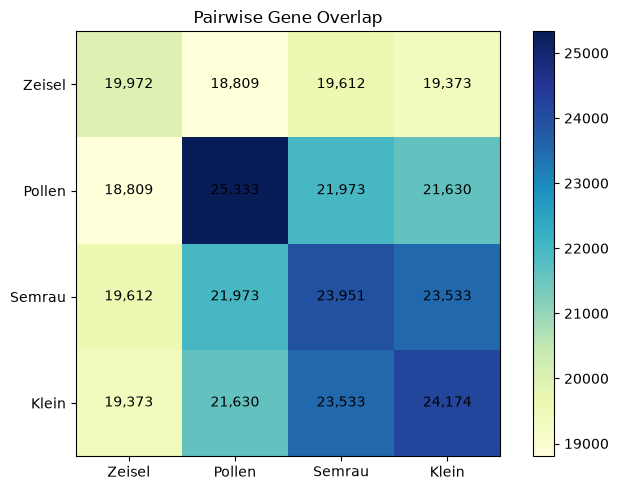


Using 18377 shared genes as the common feature space for all datasets.


In [31]:
# Visualize overlap as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
overlap_arr = overlap_matrix.values.astype(int)
im = ax.imshow(overlap_arr, cmap="YlGnBu")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{overlap_arr[i,j]:,}", ha="center", va="center", fontsize=10)
ax.set_title("Pairwise Gene Overlap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nUsing {len(shared_genes)} shared genes as the common feature space for all datasets.")


## 4. Shared Gene Space + Preprocessing

Subset all datasets to shared genes, normalize, and compute PCA in a common space. The PCA is fit on the training data and applied (transformed) to Klein.


In [33]:
# ============================================================
# Subset to shared genes, normalize, PCA
# ============================================================

shared_genes_sorted = sorted(shared_genes)
N_PCS = 50

# Subset each dataset to shared genes
def subset_and_normalize(adata, genes):
    """Subset to shared genes, normalize, log-transform."""
    sub = adata[:, adata.var_names.isin(genes)].copy()
    sub = sub[:, shared_genes_sorted].copy()
    sc.pp.filter_cells(sub, min_genes=10)
    sub.layers["counts"] = sub.X.copy()
    sc.pp.normalize_total(sub)
    sc.pp.log1p(sub)
    return sub

zeisel_sub = subset_and_normalize(zeisel_adata, shared_genes)
pollen_sub = subset_and_normalize(pollen_adata, shared_genes)
semrau_sub = subset_and_normalize(semrau_adata, shared_genes)
klein_sub = subset_and_normalize(klein_adata, shared_genes)

print("After subsetting to shared genes + normalization:")
for name, sub in [("Zeisel", zeisel_sub), ("Pollen", pollen_sub), ("Semrau", semrau_sub), ("Klein", klein_sub)]:
    print(f"  {name:8s}: {sub.n_obs} cells x {sub.n_vars} genes")

# Fit PCA on training data (Zeisel + Pollen + Semrau combined)
train_X = np.vstack([
    zeisel_sub.X if not hasattr(zeisel_sub.X, 'toarray') else zeisel_sub.X.toarray(),
    pollen_sub.X if not hasattr(pollen_sub.X, 'toarray') else pollen_sub.X.toarray(),
    semrau_sub.X if not hasattr(semrau_sub.X, 'toarray') else semrau_sub.X.toarray()
])
print(f"\nTraining PCA on combined train data: {train_X.shape}")

# Standardize before PCA
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)

pca = PCA(n_components=N_PCS, random_state=42)
pca.fit(train_X_scaled)
print(f"Variance explained by {N_PCS} PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Transform all datasets
def get_pca_embedding(adata):
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    return pca.transform(scaler.transform(X))

zeisel_pca = get_pca_embedding(zeisel_sub)
pollen_pca = get_pca_embedding(pollen_sub)
semrau_pca = get_pca_embedding(semrau_sub)
klein_pca = get_pca_embedding(klein_sub)

print(f"\nPCA embeddings:")
print(f"  Zeisel: {zeisel_pca.shape}")
print(f"  Pollen: {pollen_pca.shape}")
print(f"  Semrau: {semrau_pca.shape}")
print(f"  Klein:  {klein_pca.shape}")

After subsetting to shared genes + normalization:
  Zeisel  : 3005 cells x 18377 genes
  Pollen  : 863 cells x 18377 genes
  Semrau  : 3795 cells x 18377 genes
  Klein   : 8669 cells x 18377 genes

Training PCA on combined train data: (7663, 18377)
Variance explained by 50 PCs: 25.9%

PCA embeddings:
  Zeisel: (3005, 50)
  Pollen: (863, 50)
  Semrau: (3795, 50)
  Klein:  (8669, 50)


## 5. GAT Training

Train the unsupervised GAT autoencoder on the combined training data (Zeisel + Pollen). The model learns to refine PCA embeddings by aggregating information from KNN neighbors.


In [9]:
# ============================================================
# GAT Autoencoder definition
# ============================================================

class GATAutoencoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, embed_dim, heads=4, dropout_rate = 0.3):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout_rate)
        self.gat2 = GATConv(hidden_dim * heads, embed_dim, heads=1, dropout=dropout_rate)
        self.decoder = torch.nn.Linear(embed_dim, in_dim)

    def encode(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        h = F.dropout(h, p=self.dropout_rate, training=self.training)
        h = self.gat2(h, edge_index)
        return h

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        x_recon = self.decoder(z)
        return x_recon, z


def build_knn_graph(embeddings, k=15):
    knn = NearestNeighbors(n_neighbors=min(k, len(embeddings)-1), metric="euclidean")
    knn.fit(embeddings)
    _, indices = knn.kneighbors(embeddings)
    src, dst = [], []
    for i in range(len(embeddings)):
        for j in indices[i]:
            if i != j:
                src.append(i)
                dst.append(j)
    return torch.tensor([src, dst], dtype=torch.long)


print("GAT architecture defined.")


GAT architecture defined.


Combined training embeddings: (7663, 50)
Training graph: 7663 nodes, 107282 edges
  Epoch   0 | Loss: 142.9022
  Epoch  50 | Loss: 28.4786
  Epoch 100 | Loss: 22.0423
  Epoch 150 | Loss: 19.7296
  Epoch 200 | Loss: 19.8769
  Epoch 250 | Loss: 17.2635
  Epoch 300 | Loss: 16.7707
  Epoch 350 | Loss: 16.8043
  Epoch 400 | Loss: 17.0983
  Epoch 450 | Loss: 15.3496
  Epoch 500 | Loss: 15.6692
  Epoch 550 | Loss: 17.3281
  Epoch 600 | Loss: 17.4070
  Epoch 650 | Loss: 15.6304
  Epoch 700 | Loss: 15.4013
  Epoch 750 | Loss: 16.2826
  Epoch 799 | Loss: 17.0374


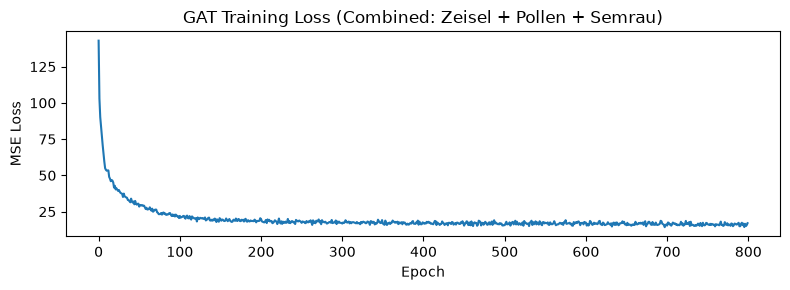


Training complete. Model has 23,506 parameters.
Restored model weights from epoch with lowest loss (14.2905).


In [ ]:
# ============================================================
# Train GAT on combined training data
# ============================================================
# Combine training PCA embeddings into one graph
train_pca_combined = np.vstack([zeisel_pca, pollen_pca, semrau_pca])
print(f"Combined training embeddings: {train_pca_combined.shape}")

# Build KNN graph on combined training data
edge_index = build_knn_graph(train_pca_combined, k=15)
x_train = torch.tensor(np.ascontiguousarray(train_pca_combined), dtype=torch.float32)
print(f"Training graph: {x_train.shape[0]} nodes, {edge_index.shape[1]} edges")

# Init model
HIDDEN_DIM = 64
EMBED_DIM = 32
EPOCHS = 600
LR = 0.005

model = GATAutoencoder(in_dim=N_PCS, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, heads=4, dropout_rate = 0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Track best model parameters
best_loss = float('inf')
best_model_path = "best_gat_model.pth"

# Train
model.train()
losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    x_recon, z = model(x_train, edge_index)
    loss = F.mse_loss(x_recon, x_train)
    loss.backward()
    optimizer.step()
    
    current_loss = loss.item()
    losses.append(current_loss)

    # Save the model if it has the lowest loss seen so far
    if current_loss < best_loss:
        best_loss = current_loss
        torch.save(model.state_dict(), best_model_path)

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d} | Loss: {current_loss:.4f}")

# Restore the model to the best saved weights
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set to evaluation mode for subsequent transfer tasks

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GAT Training Loss (Combined: Zeisel + Pollen + Semrau)")
plt.tight_layout()
plt.show()

print(f"\nTraining complete. Model has {sum(p.numel() for p in model.parameters()):,} parameters.")
print(f"Restored model weights from epoch with lowest loss ({best_loss:.4f}).")

## 6. Transfer to Klein

Apply the frozen GAT weights to Klein's PCA embeddings. Build Klein's own KNN graph, run the trained encoder — no further training.


In [49]:
# ============================================================
# Apply trained GAT to Klein (frozen weights)
# ============================================================

# Build Klein's own KNN graph
klein_edge_index = build_knn_graph(klein_pca, k=15)
x_klein = torch.tensor(np.ascontiguousarray(klein_pca), dtype=torch.float32)
print(f"Klein graph: {x_klein.shape[0]} nodes, {klein_edge_index.shape[1]} edges")

# Run frozen encoder
model.eval()
with torch.no_grad():
    _, klein_gat_embeddings = model(x_klein, klein_edge_index)
    klein_gat_embeddings = klein_gat_embeddings.numpy()

print(f"Klein GAT embeddings (transferred): {klein_gat_embeddings.shape}")

# Also get training set embeddings for reference
with torch.no_grad():
    _, train_gat_embeddings = model(x_train, edge_index)
    train_gat_embeddings = train_gat_embeddings.numpy()

# Split back into individual training datasets
n_zeisel = len(zeisel_pca)
zeisel_gat = train_gat_embeddings[:n_zeisel]
pollen_gat = train_gat_embeddings[n_zeisel:]
print(f"Training embeddings: Zeisel={zeisel_gat.shape}, Pollen={pollen_gat.shape}")


Klein graph: 8669 nodes, 121366 edges
Klein GAT embeddings (transferred): (8669, 32)
Training embeddings: Zeisel=(3005, 32), Pollen=(4658, 32)


## 7. Evaluation — Baselines + Comparison

Cluster Klein with KMeans (on raw PCA), SC3, and KMeans (on GAT-refined embeddings). Compare ARI against known cell stages.


In [50]:
# ============================================================
# Clustering on Klein — all methods
# ============================================================

true_klein = klein_sub.obs["cell_stage"] if "cell_stage" in klein_sub.obs else klein_adata.obs["cell_stage"]
k_values = [4, 8, 10]

# Attach PCA to AnnData so SC3 can find it
klein_sub.obsm["X_pca"] = np.ascontiguousarray(klein_pca)

# KMeans on raw PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_sub.obs[f"kmeans_k{k}"] = km.fit_predict(klein_pca).astype(str)

# KMeans on GAT embeddings (transferred)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_sub.obs[f"gat_k{k}"] = km.fit_predict(klein_gat_embeddings).astype(str)

# SC3
print("Running SC3 on Klein...")
sc3s.tl.consensus(klein_sub, n_clusters=k_values)

# Results
print("\n--- Klein ARI Comparison (vs cell_stage) ---")
print(f"{'k':<4} {'KMeans (PCA)':<16} {'SC3':<16} {'GAT (Transfer)':<16}")
print("-" * 52)
for k in k_values:
    km_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"kmeans_k{k}"])
    sc3_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"sc3s_{k}"])
    gat_ari = adjusted_rand_score(true_klein, klein_sub.obs[f"gat_k{k}"])
    print(f"{k:<4} {km_ari:<16.4f} {sc3_ari:<16.4f} {gat_ari:<16.4f}")


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30


Running SC3 on Klein...


INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)



--- Klein ARI Comparison (vs cell_stage) ---
k    KMeans (PCA)     SC3              GAT (Transfer)  
----------------------------------------------------
4    0.2529           0.2554           0.2457          
8    0.1399           0.0828           0.0937          
10   0.0961           0.0633           0.0934          


In [51]:
# ============================================================
# Dropout robustness test on Klein
# ============================================================

dropout_rate = 0.15
np.random.seed(42)

# Inject dropouts into Klein's raw counts
klein_noisy = klein_sub.copy()
counts = klein_noisy.layers["counts"].copy()
non_zero = counts > 0
keep = np.random.binomial(1, 1 - dropout_rate, size=counts.shape).astype(bool)
counts[non_zero & ~keep] = 0
klein_noisy.X = counts

# Re-normalize + PCA in same shared space
sc.pp.normalize_total(klein_noisy)
sc.pp.log1p(klein_noisy)
X_noisy = klein_noisy.X if not hasattr(klein_noisy.X, 'toarray') else klein_noisy.X.toarray()
klein_noisy_pca = pca.transform(scaler.transform(X_noisy))

# KMeans on noisy PCA
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_noisy.obs[f"kmeans_k{k}"] = km.fit_predict(klein_noisy_pca).astype(str)

# GAT transfer on noisy
klein_noisy_edge = build_knn_graph(klein_noisy_pca, k=15)
x_noisy = torch.tensor(np.ascontiguousarray(klein_noisy_pca), dtype=torch.float32)
with torch.no_grad():
    _, klein_noisy_gat = model(x_noisy, klein_noisy_edge)
    klein_noisy_gat = klein_noisy_gat.numpy()

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    klein_noisy.obs[f"gat_k{k}"] = km.fit_predict(klein_noisy_gat).astype(str)

# SC3 on noisy
klein_noisy.obsm["X_pca"] = np.ascontiguousarray(klein_noisy_pca)
sc3s.tl.consensus(klein_noisy, n_clusters=k_values)

# Final comparison
print("=" * 60)
print("KLEIN — Clean vs Noisy (15% dropout) ARI Comparison")
print("=" * 60)
print(f"\n{'k':<4} {'Method':<18} {'Clean':<10} {'Noisy':<10} {'Degradation':<12}")
print("-" * 54)
for k in k_values:
    for method, col in [("KMeans (PCA)", f"kmeans_k{k}"), ("SC3", f"sc3s_{k}"), ("GAT (Transfer)", f"gat_k{k}")]:
        clean_ari = adjusted_rand_score(true_klein, klein_sub.obs[col])
        noisy_ari = adjusted_rand_score(true_klein, klein_noisy.obs[col])
        deg = clean_ari - noisy_ari
        print(f"{k:<4} {method:<18} {clean_ari:<10.4f} {noisy_ari:<10.4f} {deg:+.4f}")
    print()


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30
INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)


KLEIN — Clean vs Noisy (15% dropout) ARI Comparison

k    Method             Clean      Noisy      Degradation 
------------------------------------------------------
4    KMeans (PCA)       0.2529     0.2563     -0.0035
4    SC3                0.2554     0.2958     -0.0403
4    GAT (Transfer)     0.2457     0.2449     +0.0008

8    KMeans (PCA)       0.1399     0.1435     -0.0036
8    SC3                0.0828     0.0748     +0.0081
8    GAT (Transfer)     0.0937     0.0929     +0.0008

10   KMeans (PCA)       0.0961     0.0897     +0.0064
10   SC3                0.0633     0.0709     -0.0076
10   GAT (Transfer)     0.0934     0.0952     -0.0018



In [52]:
# ============================================================
# Also validate GAT worked on training data (sanity check)
# ============================================================

# Zeisel clustering with GAT embeddings vs PCA
print("--- Training Set Validation (Zeisel, k=7) ---")
true_zeisel = zeisel_sub.obs["cell_type"]

km_pca = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_pca)
km_gat = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(zeisel_gat)

print(f"  KMeans on PCA:  ARI = {adjusted_rand_score(true_zeisel, km_pca):.4f}")
print(f"  KMeans on GAT:  ARI = {adjusted_rand_score(true_zeisel, km_gat):.4f}")
print("\nIf GAT > PCA here, the model learned useful structure from the training data.")


--- Training Set Validation (Zeisel, k=7) ---
  KMeans on PCA:  ARI = 0.7898
  KMeans on GAT:  ARI = 0.7903

If GAT > PCA here, the model learned useful structure from the training data.
